In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

In [2]:
import os
import itertools
import numpy as np
import pandas as pd

In [3]:
def read_chibio(file_name, emissions=None, overlay=False):
    m = pd.read_csv(file_name)
    
    if emissions is None:
        emissions = [x for x in m.columns
                     if x.startswith('FP')
                     and not x.endswith('base')]

    # get time in hours
    m['time'] = m['exp_time'] / 60 / 60
    # get log of the OD
    m['ln(od)'] = m['od_measured']

    # create a timedelta index
    m.index = pd.to_timedelta(m['time'], unit='h')
    # smooth OD readings taking the median over a sliding 10-minute window
    m['smooth_od'] = m.rolling('10min', min_periods=5)['od_measured'].median()
    # smooth emission readings taking the median over a sliding 10-minute window
    for em in emissions:
        m[f'smooth_{em}'] = m.rolling('10min', min_periods=5)[em].median()
        m[f'smooth_norm_{em}'] = m[f'smooth_{em}'] / (m['smooth_od'] + 1)

    for em1, em2 in itertools.combinations(emissions, 2):
        m[f'{em1}_{em2}_ratio'] = m[em1] / m[em2]
        m[f'smooth_{em1}_{em2}_ratio'] = m[f'smooth_{em1}'] / m[f'smooth_{em2}']
        m[f'smooth_norm_{em1}_{em2}_ratio'] = m[f'smooth_{em1}_{em2}_ratio'] / (m['smooth_od'] + 1)
        m[f'smooth_{em1}_{em2}_proportion'] = m[f'smooth_{em1}'] / (m[f'smooth_{em2}'] + m[f'smooth_{em1}'])
        m[f'smooth_norm_{em1}_{em2}_proportion'] = m[f'smooth_{em1}_{em2}_proportion'] / (m['smooth_od'] + 1)
    for em2, em1 in itertools.combinations(emissions, 2):
        m[f'{em1}_{em2}_ratio'] = m[em1] / m[em2]
        m[f'smooth_{em1}_{em2}_ratio'] = m[f'smooth_{em1}'] / m[f'smooth_{em2}']
        m[f'smooth_norm_{em1}_{em2}_ratio'] = m[f'smooth_{em1}_{em2}_ratio'] / (m['smooth_od'] + 1)
        m[f'smooth_{em1}_{em2}_proportion'] = m[f'smooth_{em1}'] / (m[f'smooth_{em2}'] + m[f'smooth_{em1}'])
        m[f'smooth_norm_{em1}_{em2}_proportion'] = m[f'smooth_{em1}_{em2}_proportion'] / (m['smooth_od'] + 1)
    
    return m;

In [4]:
d = {
    'M0': 'TriComm KAN no drug',
}

In [5]:
last = {}
res = []
time_add = {'3rd': 11}
for folder in ['1st', '2nd', '3rd', '4th', '5th']:
    for f in os.listdir(folder):
        if f.endswith('_data.csv'):
            m = read_chibio(os.path.join(folder, f),
                            emissions=['FP1_emit1',
                                       'FP2_emit1',
                                       'FP3_emit1'],
                            overlay=True)
            name = f.split('_')[3]
            if name not in d:
                continue
            m['vial'] = name
            m['strain'] = d[name]
            m['time'] = m['time'] + last.get(name, 0) + time_add.get(folder, 0)
            last[name] = m['time'].values[-1]
            res.append(m.reset_index(drop=True))
m = pd.concat(res).sort_values(['vial', 'time']).reset_index(drop=True)

In [6]:
m['delta'] = [0] + list(m['time'].values[1:] - m['time'].values[:-1])

jump = m.sort_values('delta')[['time', 'delta']].tail()['time'].values[-1]
jump_length = m.sort_values('delta')[['time', 'delta']].tail()['delta'].values[-1]

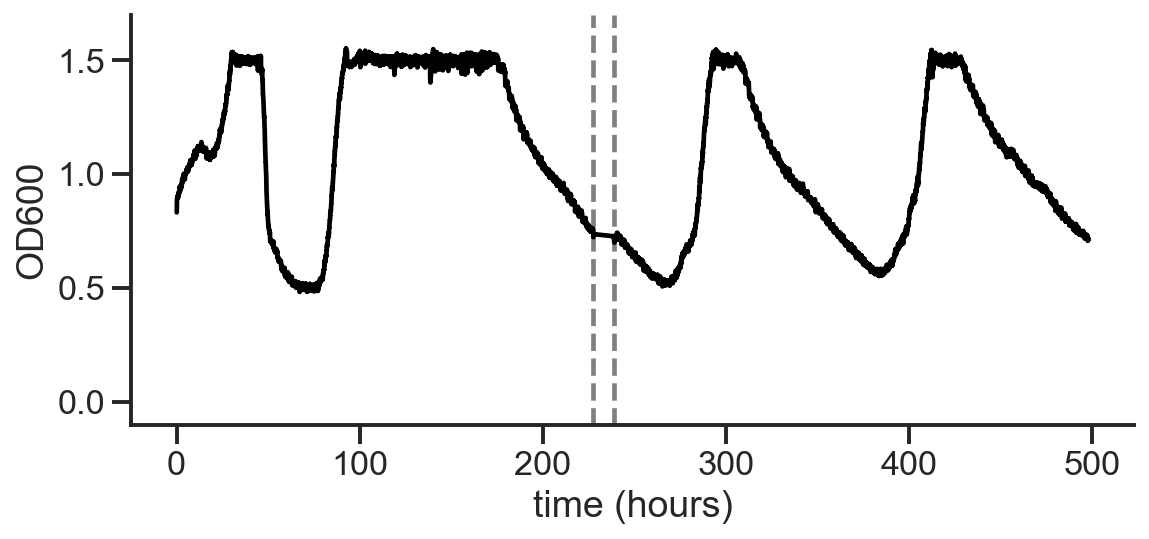

In [7]:
rp = sns.relplot(data=m.reset_index(drop=True),
                 x='time', y='smooth_od',
                 kind='line', height=4,
                 aspect=2, color='k',
                )

rp.map(plt.axvline, x=jump - jump_length, color='grey', linestyle='--',
       zorder=-1)
rp.map(plt.axvline, x=jump, color='grey', linestyle='--',
       zorder=-1)

rp.set(ylabel='OD600', xlabel='time (hours)',
      #yscale='log', 
    #xlim=(45,84),
       ylim=(-0.1, 1.7));

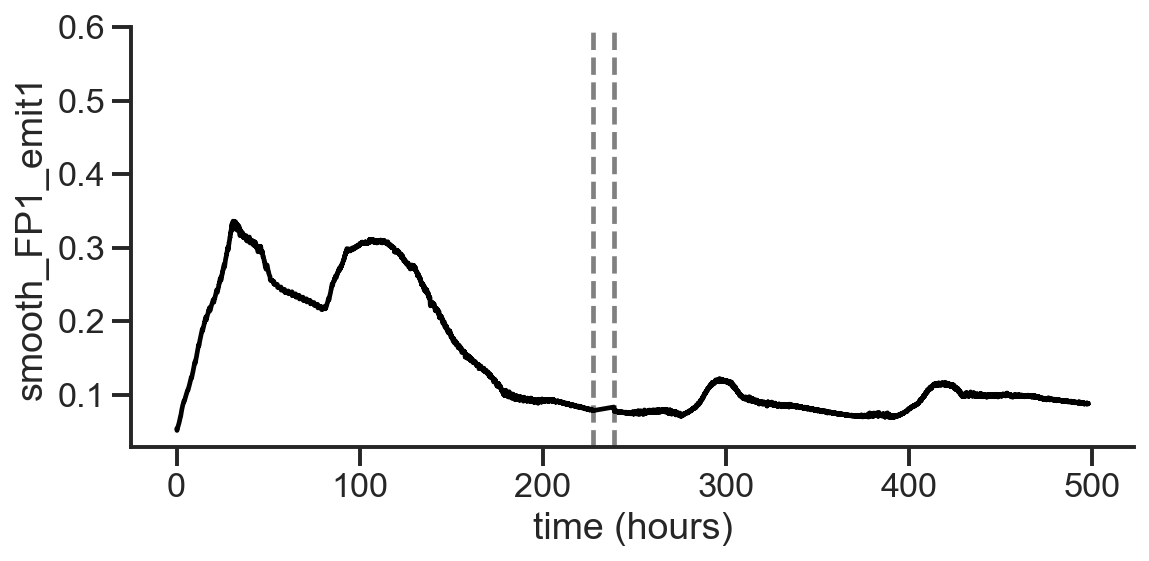

In [8]:
rp = sns.relplot(data=m.reset_index(drop=True),
                 x='time', y='smooth_FP1_emit1',
                 kind='line', height=4,
                 aspect=2, color='k',
                )

rp.map(plt.axvline, x=jump - jump_length, color='grey', linestyle='--',
       zorder=-1)
rp.map(plt.axvline, x=jump, color='grey', linestyle='--',
       zorder=-1)

rp.set(xlabel='time (hours)',
       # yscale='log',
        ylim=(0.03, 0.6
             ),
      );

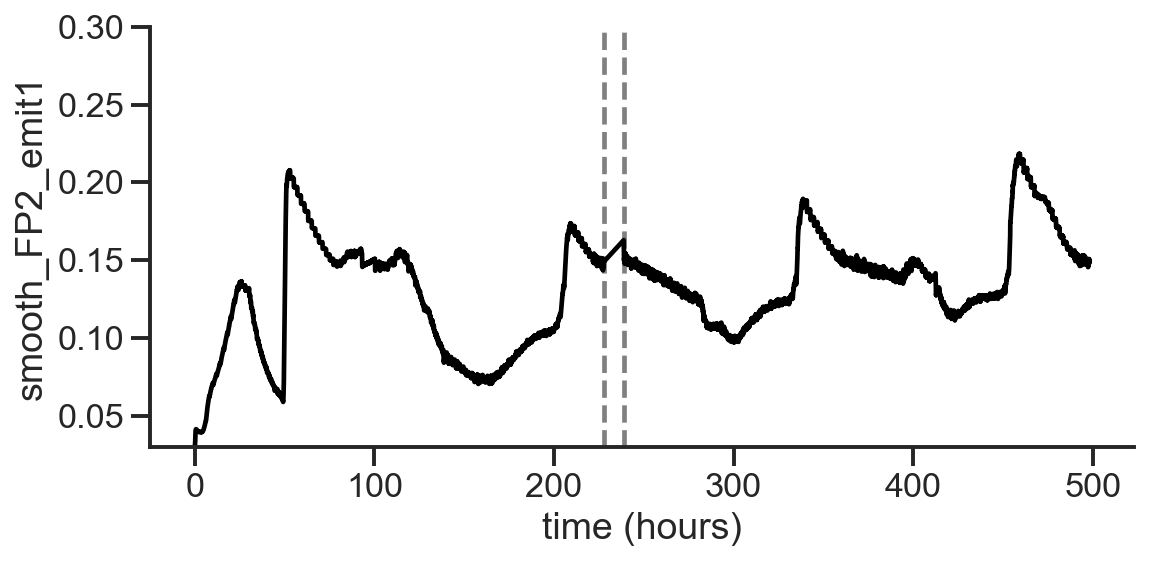

In [9]:
rp = sns.relplot(data=m.reset_index(drop=True),
                 x='time', y='smooth_FP2_emit1',
                 kind='line', height=4,
                 aspect=2, color='k',
                )

rp.map(plt.axvline, x=jump - jump_length, color='grey', linestyle='--',
       zorder=-1)
rp.map(plt.axvline, x=jump, color='grey', linestyle='--',
       zorder=-1)

rp.set(xlabel='time (hours)',
       # yscale='log',
        ylim=(0.03, 0.3
             ),
      );

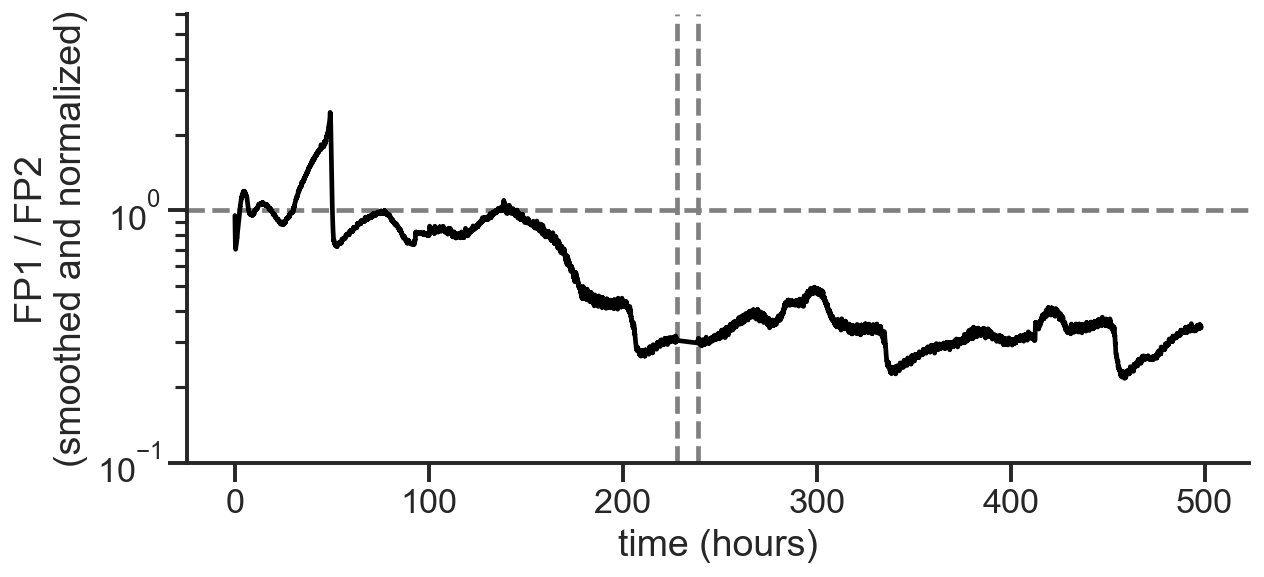

In [10]:
rp = sns.relplot(data=m.reset_index(drop=True),
                 x='time', y='smooth_norm_FP1_emit1_FP2_emit1_ratio',
                 kind='line', height=4.2,
                 aspect=2, color='k',
                )

rp.map(plt.axvline, x=jump - jump_length, color='grey', linestyle='--',
       zorder=-1)
rp.map(plt.axvline, x=jump, color='grey', linestyle='--',
       zorder=-1)

rp.map(plt.axhline, y=1, color='grey', linestyle='--',
       zorder=-1)

rp.set(xlabel='time (hours)',
       ylabel='FP1 / FP2\n(smoothed and normalized)',
       yscale='log',
        ylim=(0.1, 6
             ),
      );

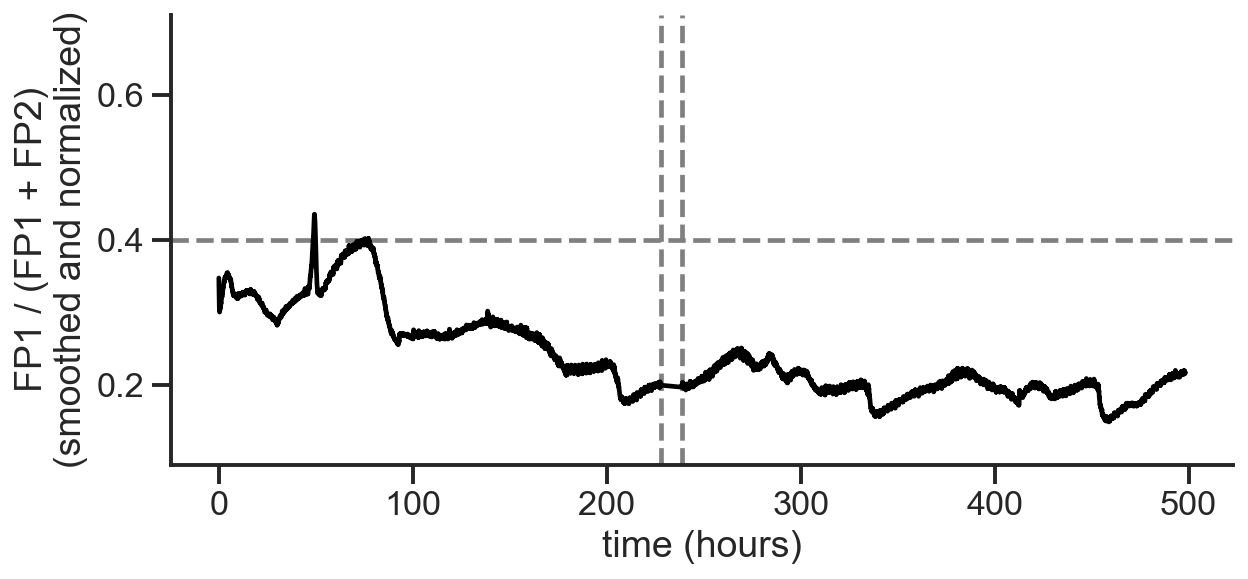

In [11]:
rp = sns.relplot(data=m.reset_index(drop=True),
                 x='time', y='smooth_norm_FP1_emit1_FP2_emit1_proportion',
                 kind='line', height=4.2,
                 aspect=2, color='k',
                )

rp.map(plt.axvline, x=jump - jump_length, color='grey', linestyle='--',
       zorder=-1)
rp.map(plt.axvline, x=jump, color='grey', linestyle='--',
       zorder=-1)

rp.map(plt.axhline, y=0.4, color='grey', linestyle='--',
       zorder=-1)

rp.set(xlabel='time (hours)',
       ylabel='FP1 / (FP1 + FP2)\n(smoothed and normalized)',
       # yscale='log',
        ylim=(0.09, 0.71
             ),
      );

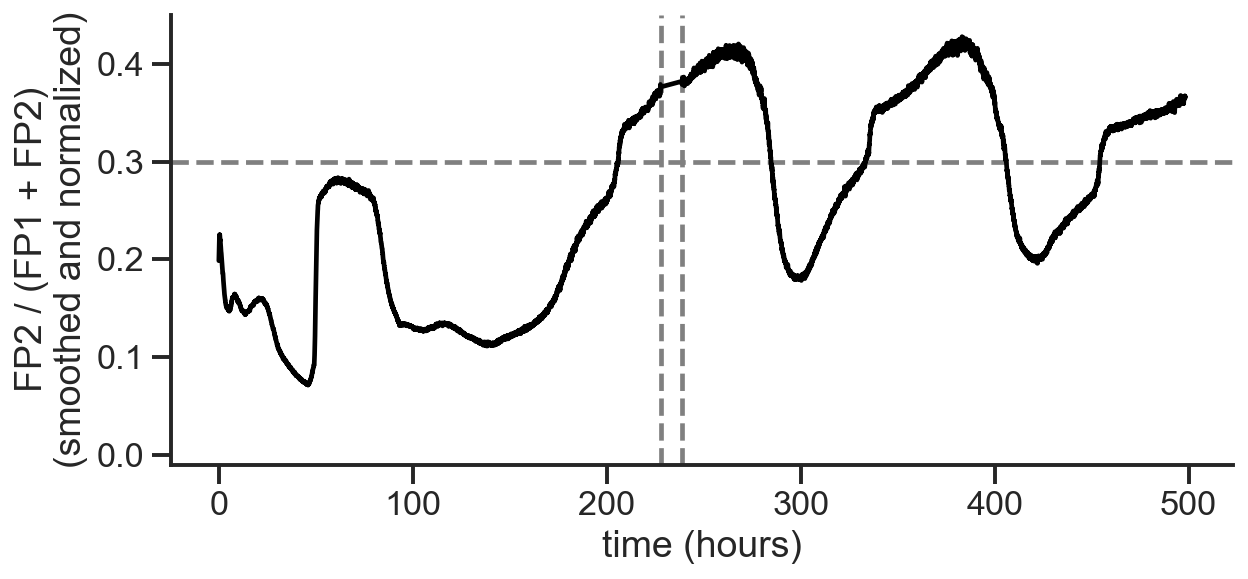

In [12]:
rp = sns.relplot(data=m.reset_index(drop=True),
                 x='time', y='smooth_norm_FP2_emit1_FP1_emit1_proportion',
                 kind='line', height=4.2,
                 aspect=2, color='k',
                )

rp.map(plt.axvline, x=jump - jump_length, color='grey', linestyle='--',
       zorder=-1)
rp.map(plt.axvline, x=jump, color='grey', linestyle='--',
       zorder=-1)

rp.map(plt.axhline, y=0.3, color='grey', linestyle='--',
       zorder=-1)

rp.set(xlabel='time (hours)',
       ylabel='FP2 / (FP1 + FP2)\n(smoothed and normalized)',
       # yscale='log',
        ylim=(-0.01, 0.45
             ),
      );

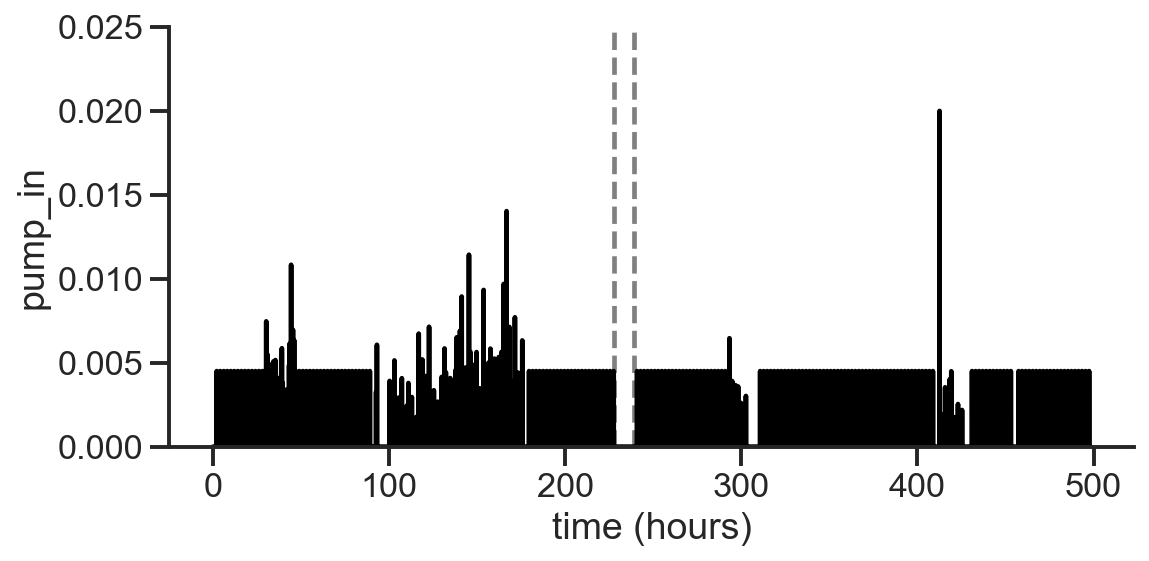

In [13]:
rp = sns.relplot(data=m.reset_index(drop=True),
                 x='time', y='pump_1_rate',
                 kind='line', height=4,
                 aspect=2, color='k',
                )

rp.map(plt.axvline, x=jump - jump_length, color='grey', linestyle='--',
       zorder=-1)
rp.map(plt.axvline, x=jump, color='grey', linestyle='--',
       zorder=-1)

rp.set(ylabel='pump_in', xlabel='time (hours)',
      #yscale='log', 
        # xlim=(45,48),
       ylim=(0, 0.025
            
            ));

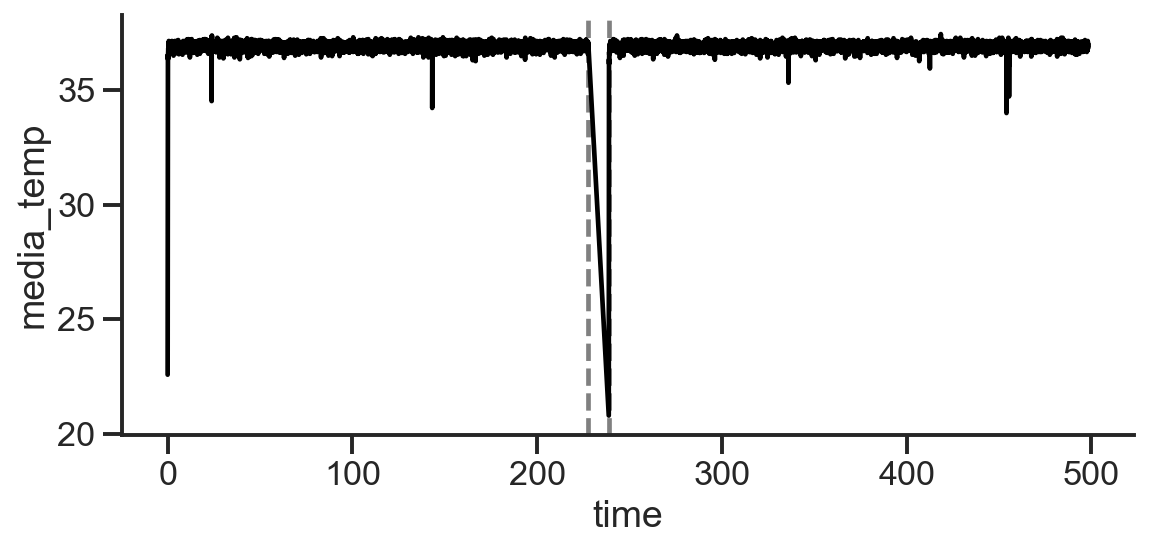

In [14]:
rp = sns.relplot(data=m.reset_index(drop=True),
                 x='time',
                 y='media_temp',
                 kind='line', height=4,
                 aspect=2, color='k',
                )

rp.map(plt.axvline, x=jump - jump_length, color='grey', linestyle='--',
       zorder=-1)
rp.map(plt.axvline, x=jump, color='grey', linestyle='--',
       zorder=-1);

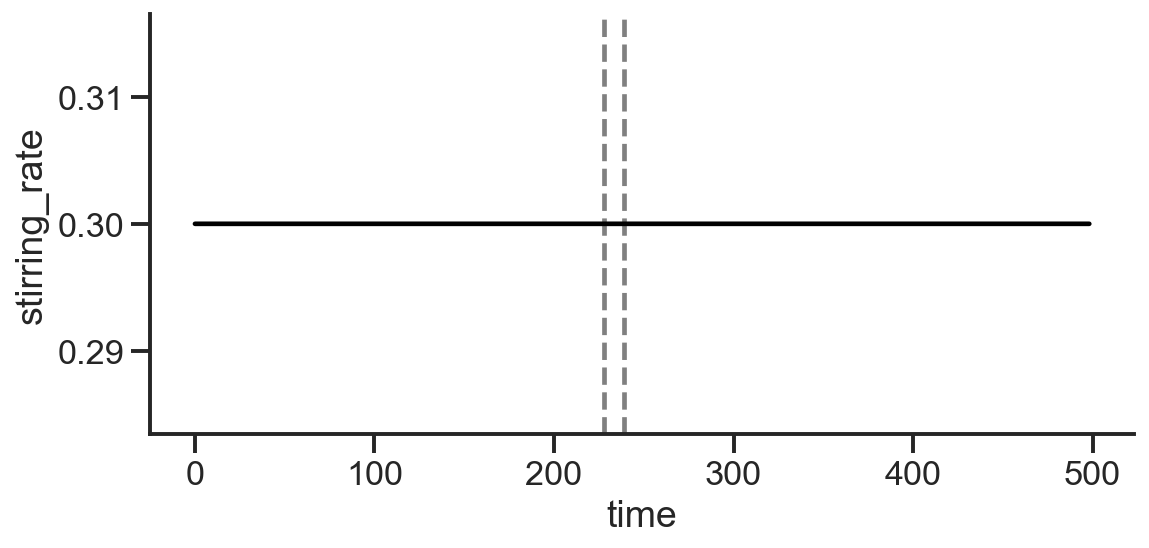

In [15]:
rp = sns.relplot(data=m.reset_index(drop=True),
                 x='time',
                 y='stirring_rate',
                 kind='line', height=4,
                 aspect=2, color='k',
                )

rp.map(plt.axvline, x=jump - jump_length, color='grey', linestyle='--',
       zorder=-1)
rp.map(plt.axvline, x=jump, color='grey', linestyle='--',
       zorder=-1);

In [16]:
cols = ['vial', 'time',
        'smooth_od', 'ln(od)', 'smooth_FP1_emit1', 'smooth_norm_FP1_emit1',
        'smooth_FP2_emit1', 'smooth_norm_FP2_emit1', 'smooth_FP3_emit1',
        'smooth_norm_FP3_emit1', 
        'FP1_emit1_FP2_emit1_ratio', 'smooth_FP1_emit1_FP2_emit1_ratio',
        'smooth_norm_FP1_emit1_FP2_emit1_ratio',
        'smooth_norm_FP1_emit1_FP2_emit1_proportion',
        'smooth_norm_FP2_emit1_FP1_emit1_proportion',
        'exp_time', 'od_measured', 'od_setpoint', 'od_zero_setpoint',
        'thermostat_setpoint', 'heating_rate', 'internal_air_temp',
        'external_air_temp', 'media_temp', 'opt_gen_act_int', 'pump_1_rate',
        'pump_2_rate', 'pump_3_rate', 'pump_4_rate', 'media_vol',
        'stirring_rate', 'LED_395nm_setpoint', 'LED_457nm_setpoint',
        'LED_500nm_setpoint', 'LED_523nm_setpoint', 'LED_595nm_setpoint',
        'LED_623nm_setpoint', 'LED_6500K_setpoint', 'laser_setpoint',
        'LED_UV_int', 'FP1_base', 'FP1_emit1', 'FP1_emit2', 'FP2_base',
        'FP2_emit1', 'FP2_emit2', 'FP3_base', 'FP3_emit1', 'FP3_emit2',
        'custom_prog_param1', 'custom_prog_param2', 'custom_prog_param3',
        'custom_prog_status', 'zigzag_target', 'growth_rate']
m = m[cols].sort_values(['vial', 'time']).reset_index(drop=True)

m.to_csv('chibio.tsv.gz', sep='\t', index=False)